In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools
import matplotlib.dates as mdates
import pandas as pd
import os

In [2]:
# Data path from AGENTS.md
data_folder = "/content/data/extracted/"

# Model identifier and Google Drive output directory
model_name = "LSTM_forecast_15m_1h_6h_2017_2019_data"
output_folder = os.path.join(
    "/content/drive/MyDrive/solar_data", "model_output", model_name
)

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# File paths for extracted datasets
trainval_images_path = os.path.join(data_folder, "trainval_images_log.npy")
trainval_pv_path = os.path.join(data_folder, "trainval_pv_log.npy")
test_images_path = os.path.join(data_folder, "test_images_log.npy")
test_pv_path = os.path.join(data_folder, "test_pv_log.npy")

times_trainval_path = os.path.join(data_folder, "times_trainval.npy")
times_test_path = os.path.join(data_folder, "times_test.npy")

print("data_folder:   ", data_folder)
print("output_folder: ", output_folder)
print("trainval_pv:   ", trainval_pv_path)
print("test_pv:       ", test_pv_path)
print("times_trainval:", times_trainval_path)
print("times_test:    ", times_test_path)

data_folder:    /content/data/extracted/
output_folder:  /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data
trainval_pv:    /content/data/extracted/trainval_pv_log.npy
test_pv:        /content/data/extracted/test_pv_log.npy
times_trainval: /content/data/extracted/times_trainval.npy
times_test:     /content/data/extracted/times_test.npy


In [3]:
# Model & Forecast Horizon Parameters
# SEQ_LEN: Number of historical 1-minute time steps used as input (16 minutes)
SEQ_LEN = 16

# Stanford Solar Forecasting Dataset is logged at 1-minute intervals.
HORIZON_MAP = {
    "15min": 15,
    "1hour": 60,
    "6hours": 360,
}

FORECAST_HORIZONS = [15, 60, 360]
HORIZON_NAMES = ["15 min", "1 hour", "6 hours"]
NUM_TARGETS = len(FORECAST_HORIZONS)

# Training hyper-parameters
NUM_FOLDS = 10  # 10-fold cross validation
NUM_EPOCHS = 200  # Max epochs (EarlyStopping will halt earlier)
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 10  # Early stopping patience

print(f"Sequence Length (History Window): {SEQ_LEN} minutes")
print(f"Target Horizons:                  {FORECAST_HORIZONS} steps ({HORIZON_NAMES})")
print(f"Number of Target Outputs:         {NUM_TARGETS}")
print(f"Cross-Validation Folds:           {NUM_FOLDS}")

Sequence Length (History Window): 16 minutes
Target Horizons:                  [15, 60, 360] steps (['15 min', '1 hour', '6 hours'])
Number of Target Outputs:         3
Cross-Validation Folds:           10


In [4]:
trainval_pv = np.load(trainval_pv_path).astype(np.float32)
test_pv = np.load(test_pv_path).astype(np.float32)

times_trainval = np.load(times_trainval_path, allow_pickle=True)
times_test = np.load(times_test_path, allow_pickle=True)

print(f"trainval_pv shape: {trainval_pv.shape} | times: {times_trainval.shape}")
print(f"test_pv shape:     {test_pv.shape} | times: {times_test.shape}")

trainval_pv shape: (349372,) | times: (349372,)
test_pv shape:     (14003,) | times: (14003,)


In [5]:
def create_day_aware_forecast_sequences(
    pv_array, times_array, seq_len=16, horizons=[15, 60, 360]
):
    """
    Constructs (X, y, sequence_dates, sequence_times) sequences
    ensuring that no sequence crosses overnight boundaries or
    distinct calendar dates.

    Parameters:
        pv_array: 1D numpy array of PV power generation values (kW)
        times_array: 1D numpy array of timestamps (datetime objects)
        seq_len: Number of historical lag steps for input X
        horizons: List/tuple of forecast steps ahead [15, 60, 360]

    Returns:
        X: Array of shape (N, seq_len, 1)
        y: Array of shape (N, len(horizons)) [or (N,) if single horizon]
        valid_dates: Array of base calendar dates (N,)
        valid_times: Array of target forecast timestamps (N, len(horizons))
    """
    is_multi = isinstance(horizons, (list, tuple, np.ndarray))
    if is_multi:
        horizon_list = list(horizons)
        max_horizon = max(horizon_list)
    else:
        horizon_list = [horizons]
        max_horizon = horizons

    dates = np.array(
        [
            (
                t.date()
                if isinstance(t, (datetime.datetime, datetime.date))
                else pd.to_datetime(t).date()
            )
            for t in times_array
        ]
    )

    unique_dates = np.unique(dates)

    X_list, y_list = [], []
    valid_dates_list = []
    valid_times_list = []

    for d in unique_dates:
        day_indices = np.where(dates == d)[0]
        num_day_points = len(day_indices)

        # Skip days that do not have enough points for sequence + largest horizon
        if num_day_points <= seq_len + max_horizon:
            continue

        day_pv = pv_array[day_indices]
        day_times = times_array[day_indices]

        for i in range(seq_len, num_day_points - max_horizon):
            seq_x = day_pv[i - seq_len : i]

            if is_multi:
                seq_y = [day_pv[i + h] for h in horizon_list]
                target_times = [day_times[i + h] for h in horizon_list]
            else:
                seq_y = day_pv[i + horizon_list[0]]
                target_times = day_times[i + horizon_list[0]]

            X_list.append(seq_x)
            y_list.append(seq_y)
            valid_dates_list.append(d)
            valid_times_list.append(target_times)

    X = np.expand_dims(
        np.array(X_list, dtype=np.float32), axis=-1
    )  # Shape: (N, seq_len, 1)

    y = np.array(y_list, dtype=np.float32)  # Shape: (N, num_horizons) or (N,)

    valid_dates = np.array(valid_dates_list)
    valid_times = np.array(valid_times_list)

    return X, y, valid_dates, valid_times


X_trainval, y_trainval, dates_trainval_seq, times_trainval_seq = (
    create_day_aware_forecast_sequences(
        trainval_pv, times_trainval, seq_len=SEQ_LEN, horizons=FORECAST_HORIZONS
    )
)

X_test, y_test, dates_test_seq, times_test_seq = create_day_aware_forecast_sequences(
    test_pv, times_test, seq_len=SEQ_LEN, horizons=FORECAST_HORIZONS
)

print(f"X_trainval shape: {X_trainval.shape}, y_trainval shape: {y_trainval.shape}")
print(f"X_test shape:     {X_test.shape}, y_test shape:     {y_test.shape}")
print(
    f"dates_trainval:   {dates_trainval_seq.shape}, times_trainval: {times_trainval_seq.shape}"
)
print(
    f"dates_test:       {dates_test_seq.shape}, times_test:       {times_test_seq.shape}"
)

X_trainval shape: (163317, 16, 1), y_trainval shape: (163317, 3)
X_test shape:     (6483, 16, 1), y_test shape:     (6483, 3)
dates_trainval:   (163317,), times_trainval: (163317, 3)
dates_test:       (6483,), times_test:       (6483, 3)


In [6]:
def day_block_shuffle_indices(dates_array, seed=1):
    """
    Groups sequence indices by day, shuffles whole day blocks,
    and concatenates them to prevent temporal leakage across folds.
    """
    unique_dates = np.unique(dates_array)

    np.random.seed(seed)
    np.random.shuffle(unique_dates)

    shuffled_idx_blocks = []

    for d in unique_dates:
        shuffled_idx_blocks.append(np.where(dates_array == d)[0])

    shuffled_indices = np.asarray(
        list(itertools.chain.from_iterable(shuffled_idx_blocks))
    )

    return shuffled_indices


def cv_split_indices(shuffled_indices, fold_index, num_folds=10):
    """
    Splits day-block shuffled indices into train and validation
    sets for a given fold.
    """
    num_samples = len(shuffled_indices)
    indices = np.arange(num_samples)

    val_mask = np.zeros(num_samples, dtype=bool)

    val_start = int(fold_index / num_folds * num_samples)
    val_end = int((fold_index + 1) / num_folds * num_samples)

    val_mask[val_start:val_end] = True

    val_idx = indices[val_mask]
    train_idx = indices[~val_mask]

    # Local shuffle
    np.random.seed(fold_index)
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    return (shuffled_indices[train_idx], shuffled_indices[val_idx])


def build_tf_dataset(X, y, indices, batch_size=256, is_training=True):
    """
    Builds an optimized tf.data.Dataset pipeline.
    """
    X_sub = X[indices]
    y_sub = y[indices]

    ds = tf.data.Dataset.from_tensor_slices((X_sub, y_sub))

    if is_training:
        ds = ds.shuffle(buffer_size=min(len(indices), 10000), seed=42)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds

In [7]:
def build_lstm_forecast_model(
    seq_len=16,
    num_features=1,
    num_outputs=3,
    lstm_units=(64, 64),
    dense_units=128,
    drop_rate=0.2,
):
    """
    Builds a 2-layer Stacked LSTM model with Dropout
    and Multi-Horizon Dense regression output.

    Inputs:
        (batch_size, seq_len, num_features)
    Outputs:
        (batch_size, num_outputs) representing PV forecast values
        for the target horizons [15m, 1h, 6h].
    """
    inputs = keras.Input(shape=(seq_len, num_features), name="pv_sequence_input")

    # First LSTM layer
    x = keras.layers.LSTM(lstm_units[0], return_sequences=True, name="lstm_1")(inputs)
    x = keras.layers.Dropout(drop_rate, name="drop_1")(x)

    # Second LSTM layer
    x = keras.layers.LSTM(lstm_units[1], return_sequences=False, name="lstm_2")(x)
    x = keras.layers.Dropout(drop_rate, name="drop_2")(x)

    # Fully-connected projection head
    x = keras.layers.Dense(dense_units, activation="relu", name="dense_1")(x)
    x = keras.layers.Dropout(drop_rate, name="drop_3")(x)

    outputs = keras.layers.Dense(
        units=num_outputs, activation="linear", name="pv_forecast"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"LSTM_Solar_Forecaster_{num_outputs}Horizons",
    )

    return model


sample_model = build_lstm_forecast_model(
    seq_len=SEQ_LEN, num_features=1, num_outputs=NUM_TARGETS
)

sample_model.summary()

Model: "LSTM_Solar_Forecaster_3Horizons"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pv_sequence_input (InputLayer)  │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pv_forecast (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,627 (229.01 KB)

 Trainable params: 58,627 (229.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
indices_shuffled = day_block_shuffle_indices(dates_trainval_seq, seed=1)

train_loss_hist = []
val_loss_hist = []

train_mae_hist = []
val_mae_hist = []

for fold in range(NUM_FOLDS):
    print(f"\n{'='*25} FOLD {fold + 1} / {NUM_FOLDS} {'='*25}")

    train_idx, val_idx = cv_split_indices(
        indices_shuffled, fold_index=fold, num_folds=NUM_FOLDS
    )

    # Datasets
    ds_train = build_tf_dataset(
        X_trainval, y_trainval, train_idx, batch_size=BATCH_SIZE, is_training=True
    )

    ds_val = build_tf_dataset(
        X_trainval, y_trainval, val_idx, batch_size=BATCH_SIZE, is_training=False
    )

    # Model definition
    model = build_lstm_forecast_model(
        seq_len=SEQ_LEN,
        num_features=1,
        num_outputs=NUM_TARGETS,
        lstm_units=(64, 64),
        dense_units=128,
        drop_rate=0.2,
    )

    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    # Callbacks
    checkpoint_dir = os.path.join(output_folder, f"repetition_{fold + 1}")
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(
        checkpoint_dir, f"best_model_repetition_{fold + 1}.h5"
    )

    earlystop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
        verbose=1,
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    # Training
    history = model.fit(
        ds_train,
        epochs=NUM_EPOCHS,
        validation_data=ds_val,
        callbacks=[earlystop, checkpoint, reduce_lr],
        verbose=1,
    )

    # Store training history
    train_loss_hist.append(history.history["loss"])
    val_loss_hist.append(history.history["val_loss"])
    train_mae_hist.append(history.history["mae"])
    val_mae_hist.append(history.history["val_mae"])

    # Save history arrays
    np.save(
        os.path.join(output_folder, "train_loss_hist.npy"),
        np.array(train_loss_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "val_loss_hist.npy"),
        np.array(val_loss_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "train_mae_hist.npy"),
        np.array(train_mae_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "val_mae_hist.npy"),
        np.array(val_mae_hist, dtype=object),
    )


========================= FOLD 1 / 10 =========================
Epoch 1/200
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 57.5671 - mae: 5.2639
Epoch 1: val_loss improved from None to 15.89878, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 27.6735 - mae: 3.5948 - val_loss: 15.8988 - val_mae: 2.3824 - learning_rate: 0.0010
Epoch 2/200
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.6832 - mae: 2.8379
Epoch 2: val_loss improved from 15.89878 to 15.47706, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 16.3203 - mae: 2.7927 - val_loss: 15.4771 - val_mae: 2.4203 - learning_rate: 0.0010
Epoch 3/200
571/575 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 15.8681 - mae: 2.7328
Epoch 3: val_loss improved from 15.47706 to 14.68878, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 15.6615 - mae: 2.7104 - val_loss: 14.6888 - val_mae: 2.4064 - learning_rate: 0.0010
Epoch 4/200
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.2951 - mae: 2.6710
Epoch 4: val_loss improved from 14.68878 to 14.56302, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 15.1734 - mae: 2.6553 - val_loss: 14.5630 - val_mae: 2.3426 - learning_rate: 0.0010
Epoch 5/200
573/575 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14.9486 - mae: 2.6236
Epoch 5: val_loss did not improve from 14.56302
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 14.8489 - mae: 2.6118 - val_loss: 14.7044 - val_mae: 2.4243 - learning_rate: 0.0010
Epoch 6/200
571/575 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14.7346 - mae: 2.5933
Epoch 6: val_loss did not improve from 14.56302
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 14.6181 - mae: 2.5792 - val_loss: 14.7738 - val_mae: 2.2903 - learning_rate: 0.0010
Epoch 7/200
572/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.5582 - mae: 2.5641
Epoch 7: val_loss improved from 14.56302 to 14.06726, saving model to /content/drive/MyDrive/s

...


Epoch 42: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_10/best_model_repetition_10.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 12.7726 - mae: 2.2866 - val_loss: 10.8199 - val_mae: 1.9125 - learning_rate: 1.2500e-04
Epoch 43/200
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12.7972 - mae: 2.2847
Epoch 43: val_loss did not improve from 10.81990
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 12.7559 - mae: 2.2808 - val_loss: 10.9523 - val_mae: 1.9323 - learning_rate: 1.2500e-04
Epoch 44/200
569/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.8158 - mae: 2.2847
Epoch 44: val_loss improved from 10.81990 to 10.80575, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_10/best_model_repetition_10.h5



Epoch 44: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_10/best_model_repetition_10.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 12.7506 - mae: 2.2799 - val_loss: 10.8057 - val_mae: 1.8894 - learning_rate: 1.2500e-04
Epoch 45/200
571/575 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.7963 - mae: 2.2830
Epoch 45: val_loss did not improve from 10.80575
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 12.7597 - mae: 2.2816 - val_loss: 10.8333 - val_mae: 1.9100 - learning_rate: 1.2500e-04
Epoch 46/200
572/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.8128 - mae: 2.2877
Epoch 46: val_loss did not improve from 10.80575
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 12.7607 - mae: 2.2840 - val_loss: 10.8848 - val_mae: 1.8897 - learning_rate: 1.2500e-04
Epoch 47/200
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.7811 - mae: 2.2809
Epoch 47: val_loss did not improve from 10.80575

Epoch 47: ReduceLROnPla


Epoch 48: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_10/best_model_repetition_10.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 12.7262 - mae: 2.2779 - val_loss: 10.7766 - val_mae: 1.8986 - learning_rate: 6.2500e-05
Epoch 49/200
571/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.7957 - mae: 2.2815
Epoch 49: val_loss did not improve from 10.77657
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 12.7357 - mae: 2.2791 - val_loss: 10.8055 - val_mae: 1.8855 - learning_rate: 6.2500e-05
Epoch 50/200
571/575 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.7508 - mae: 2.2767
Epoch 50: val_loss did not improve from 10.77657
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 12.7271 - mae: 2.2769 - val_loss: 10.7900 - val_mae: 1.9047 - learning_rate: 6.2500e-05
Epoch 51/200
572/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.7730 - mae: 2.2813
Epoch 51: val_loss improved from 10.77657 to 10.76702, saving model to /


Epoch 51: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_10/best_model_repetition_10.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 12.7121 - mae: 2.2774 - val_loss: 10.7670 - val_mae: 1.8953 - learning_rate: 6.2500e-05
Epoch 52/200
571/575 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.7863 - mae: 2.2816
Epoch 52: val_loss did not improve from 10.76702
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 12.7058 - mae: 2.2770 - val_loss: 10.7813 - val_mae: 1.8919 - learning_rate: 6.2500e-05
Epoch 53/200
570/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.7507 - mae: 2.2740
Epoch 53: val_loss did not improve from 10.76702
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 12.6951 - mae: 2.2732 - val_loss: 10.7672 - val_mae: 1.9043 - learning_rate: 6.2500e-05
Epoch 54/200
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12.8149 - mae: 2.2827
Epoch 54: val_loss did not improve from 10.76702

Epoch 54: ReduceLROnPla


Epoch 55: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_10/best_model_repetition_10.h5
575/575 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 12.6843 - mae: 2.2715 - val_loss: 10.7584 - val_mae: 1.8948 - learning_rate: 3.1250e-05
Epoch 56/200
572/575 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.7397 - mae: 2.2742
Epoch 56: val_loss did not improve from 10.75837
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 12.6894 - mae: 2.2730 - val_loss: 10.7876 - val_mae: 1.8954 - learning_rate: 3.1250e-05
Epoch 57/200
574/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.7414 - mae: 2.2773
Epoch 57: val_loss did not improve from 10.75837
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 12.6819 - mae: 2.2736 - val_loss: 10.7966 - val_mae: 1.8897 - learning_rate: 3.1250e-05
Epoch 58/200
572/575 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.7743 - mae: 2.2754
Epoch 58: val_loss did not improve from 10.75837

Epoch 58: ReduceLROnP

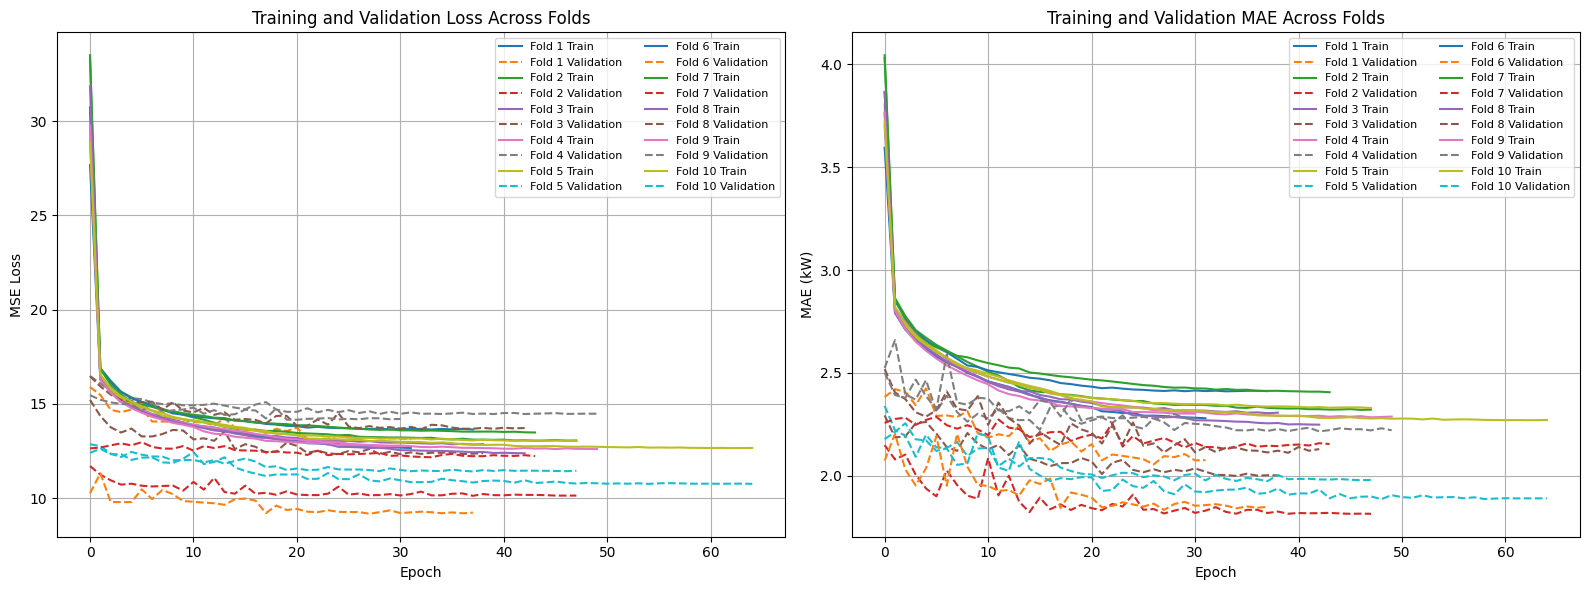

In [9]:
fig, axarr = plt.subplots(1, 2, figsize=(16, 6))

# TRAINING & VALIDATION LOSS
for fold in range(NUM_FOLDS):
    axarr[0].plot(train_loss_hist[fold], label=f"Fold {fold + 1} Train")
    axarr[0].plot(
        val_loss_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[0].set_xlabel("Epoch")
axarr[0].set_ylabel("MSE Loss")
axarr[0].set_title("Training and Validation Loss Across Folds")
axarr[0].legend(ncol=2, fontsize=8)
axarr[0].grid(True)

# TRAINING & VALIDATION MAE
for fold in range(NUM_FOLDS):
    axarr[1].plot(train_mae_hist[fold], label=f"Fold {fold + 1} Train")
    axarr[1].plot(
        val_mae_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[1].set_xlabel("Epoch")
axarr[1].set_ylabel("MAE (kW)")
axarr[1].set_title("Training and Validation MAE Across Folds")
axarr[1].legend(ncol=2, fontsize=8)
axarr[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
best_train_loss_mse = np.zeros(NUM_FOLDS)
best_val_loss_mse = np.zeros(NUM_FOLDS)

print(f"{'Fold':<8} | {'Best Train RMSE (kW)':<22} | {'Best Val RMSE (kW)':<20}")
print("-" * 56)

for i in range(NUM_FOLDS):
    best_val_loss_mse[i] = np.min(val_loss_hist[i])
    idx = np.argmin(val_loss_hist[i])
    best_train_loss_mse[i] = train_loss_hist[i][idx]

    train_rmse = np.sqrt(best_train_loss_mse[i])
    val_rmse = np.sqrt(best_val_loss_mse[i])
    print(f"Fold {i + 1:02d}  | {train_rmse:<22.3f} | {val_rmse:<20.3f}")

print("-" * 56)
print(f"Mean Train RMSE:      {np.mean(np.sqrt(best_train_loss_mse)):.3f} kW")
print(f"Mean Validation RMSE: {np.mean(np.sqrt(best_val_loss_mse)):.3f} kW")

Fold     | Best Train RMSE (kW)   | Best Val RMSE (kW)  
--------------------------------------------------------
Fold 01  | 3.594                  | 3.623               
Fold 02  | 3.620                  | 3.182               
Fold 03  | 3.600                  | 3.512               
Fold 04  | 3.557                  | 3.803               
Fold 05  | 3.615                  | 3.379               
Fold 06  | 3.697                  | 3.028               
Fold 07  | 3.686                  | 3.489               
Fold 08  | 3.539                  | 3.695               
Fold 09  | 3.599                  | 3.763               
Fold 10  | 3.561                  | 3.280               
--------------------------------------------------------
Mean Train RMSE:      3.607 kW
Mean Validation RMSE: 3.475 kW


In [11]:
predictions = np.zeros((NUM_FOLDS, len(X_test), NUM_TARGETS), dtype=np.float32)

for fold in range(NUM_FOLDS):
    checkpoint_path = os.path.join(
        output_folder, f"repetition_{fold + 1}", f"best_model_repetition_{fold + 1}.h5"
    )

    print(f"Loading fold {fold + 1} model from: {checkpoint_path}")
    fold_model = keras.models.load_model(checkpoint_path, compile=False)

    pred = fold_model.predict(X_test, batch_size=512, verbose=0)
    if pred.ndim == 1 or (pred.ndim == 2 and pred.shape[1] == 1 and NUM_TARGETS == 1):
        pred = np.reshape(pred, (-1, 1))

    predictions[fold] = pred

# Save individual fold predictions
np.save(os.path.join(output_folder, "test_predictions_all_folds.npy"), predictions)

# Ensemble average across folds
ensemble_predictions = np.mean(predictions, axis=0)

np.save(
    os.path.join(output_folder, "test_predictions_ensemble.npy"), ensemble_predictions
)
print(f"\nEnsemble predictions saved. Shape: {ensemble_predictions.shape}")

Loading fold 1 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_1/best_model_repetition_1.h5
Loading fold 2 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_2/best_model_repetition_2.h5
Loading fold 3 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_3/best_model_repetition_3.h5
Loading fold 4 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_4/best_model_repetition_4.h5
Loading fold 5 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_5/best_model_repetition_5.h5
Loading fold 6 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_6h_2017_2019_data/repetition_6/best_model_repetition_6.h5
Loading fold 7 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_for

COMPLETE TEST SET FORECAST RESULTS (6,483 Sequences)
Horizon      | Lead Steps   | Test RMSE (kW)   | Test MAE (kW) 
--------------------------------------------------------------------
15 min       | 15           | 3.014            | 1.537         
1 hour       | 60           | 3.966            | 2.304         
6 hours      | 360          | 5.569            | 4.168         
--------------------------------------------------------------------
OVERALL      | All          | 4.314            | 2.670         


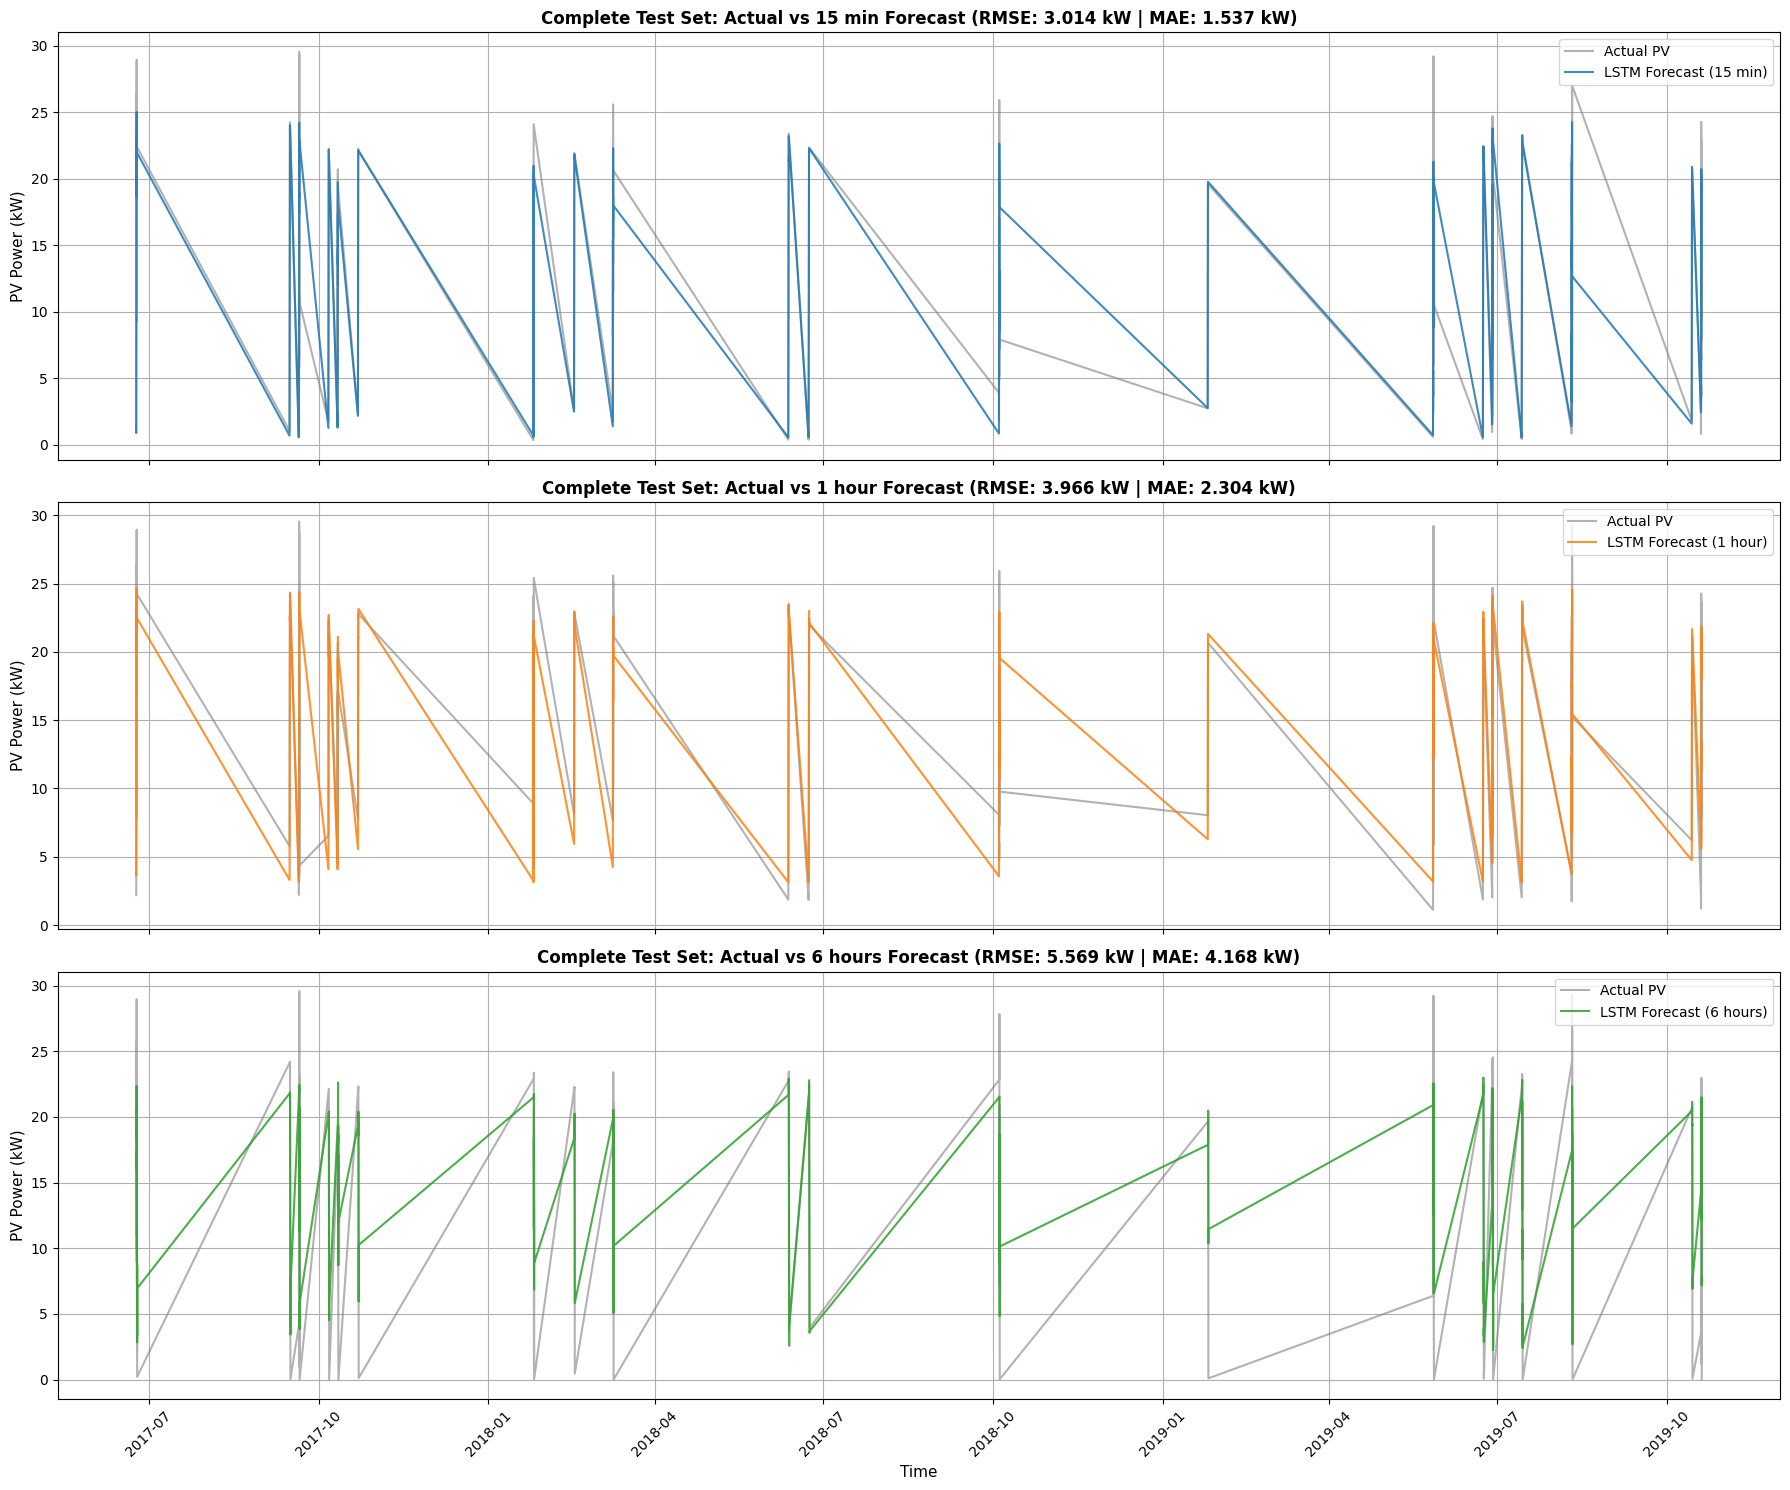

In [12]:
# TEST SET EVALUATION ACROSS ALL HORIZONS
errors = ensemble_predictions - y_test  # Shape: (N, NUM_TARGETS)

print("=" * 68)
print(f"COMPLETE TEST SET FORECAST RESULTS ({len(y_test):,} Sequences)")
print("=" * 68)
print(
    f"{'Horizon':<12} | {'Lead Steps':<12} | {'Test RMSE (kW)':<16} | {'Test MAE (kW)':<14}"
)
print("-" * 68)

horizon_metrics = {}
for k, (h_name, h_steps) in enumerate(zip(HORIZON_NAMES, FORECAST_HORIZONS)):
    h_err = errors[:, k] if errors.ndim > 1 else errors
    h_rmse = np.sqrt(np.mean(np.square(h_err)))
    h_mae = np.mean(np.abs(h_err))
    horizon_metrics[h_name] = {"rmse": h_rmse, "mae": h_mae}
    print(f"{h_name:<12} | {h_steps:<12} | {h_rmse:<16.3f} | {h_mae:<14.3f}")

print("-" * 68)
rmse_overall = np.sqrt(np.mean(np.square(errors)))
mae_overall = np.mean(np.abs(errors))
print(f"{'OVERALL':<12} | {'All':<12} | {rmse_overall:<16.3f} | {mae_overall:<14.3f}")
print("=" * 68)

# TIME-SERIES PLOTS FOR COMPLETE TEST SET
fig, axes = plt.subplots(NUM_TARGETS, 1, figsize=(18, 5 * NUM_TARGETS), sharex=True)
if NUM_TARGETS == 1:
    axes = [axes]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for k, (h_name, h_color) in enumerate(zip(HORIZON_NAMES, colors)):
    ax = axes[k]
    h_times = times_test_seq[:, k] if times_test_seq.ndim > 1 else times_test_seq
    h_y_true = y_test[:, k] if y_test.ndim > 1 else y_test
    h_y_pred = (
        ensemble_predictions[:, k]
        if ensemble_predictions.ndim > 1
        else ensemble_predictions
    )

    ax.plot(h_times, h_y_true, color="#808080", alpha=0.6, label="Actual PV")
    ax.plot(
        h_times, h_y_pred, color=h_color, alpha=0.85, label=f"LSTM Forecast ({h_name})"
    )
    ax.set_ylabel("PV Power (kW)", fontsize=11)
    ax.set_title(
        f"Complete Test Set: Actual vs {h_name} Forecast "
        f"(RMSE: {horizon_metrics[h_name]['rmse']:.3f} kW | MAE: {horizon_metrics[h_name]['mae']:.3f} kW)",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(loc="upper right")
    ax.grid(True)

axes[-1].set_xlabel("Time", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# SUNNY AND CLOUDY DATES FROM THE SKIPP'D PAPER
sunny_dates = [
    (2017, 9, 15),
    (2017, 10, 6),
    (2017, 10, 22),
    (2018, 2, 16),
    (2018, 6, 12),
    (2018, 6, 23),
    (2019, 1, 25),
    (2019, 6, 23),
    (2019, 7, 14),
    (2019, 10, 14),
]

cloudy_dates = [
    (2017, 6, 24),
    (2017, 9, 20),
    (2017, 10, 11),
    (2018, 1, 25),
    (2018, 3, 9),
    (2018, 10, 4),
    (2019, 5, 27),
    (2019, 6, 28),
    (2019, 8, 10),
    (2019, 10, 19),
]

sunny_dates_test = [datetime.date(y, m, d) for y, m, d in sunny_dates]
cloudy_dates_test = [datetime.date(y, m, d) for y, m, d in cloudy_dates]

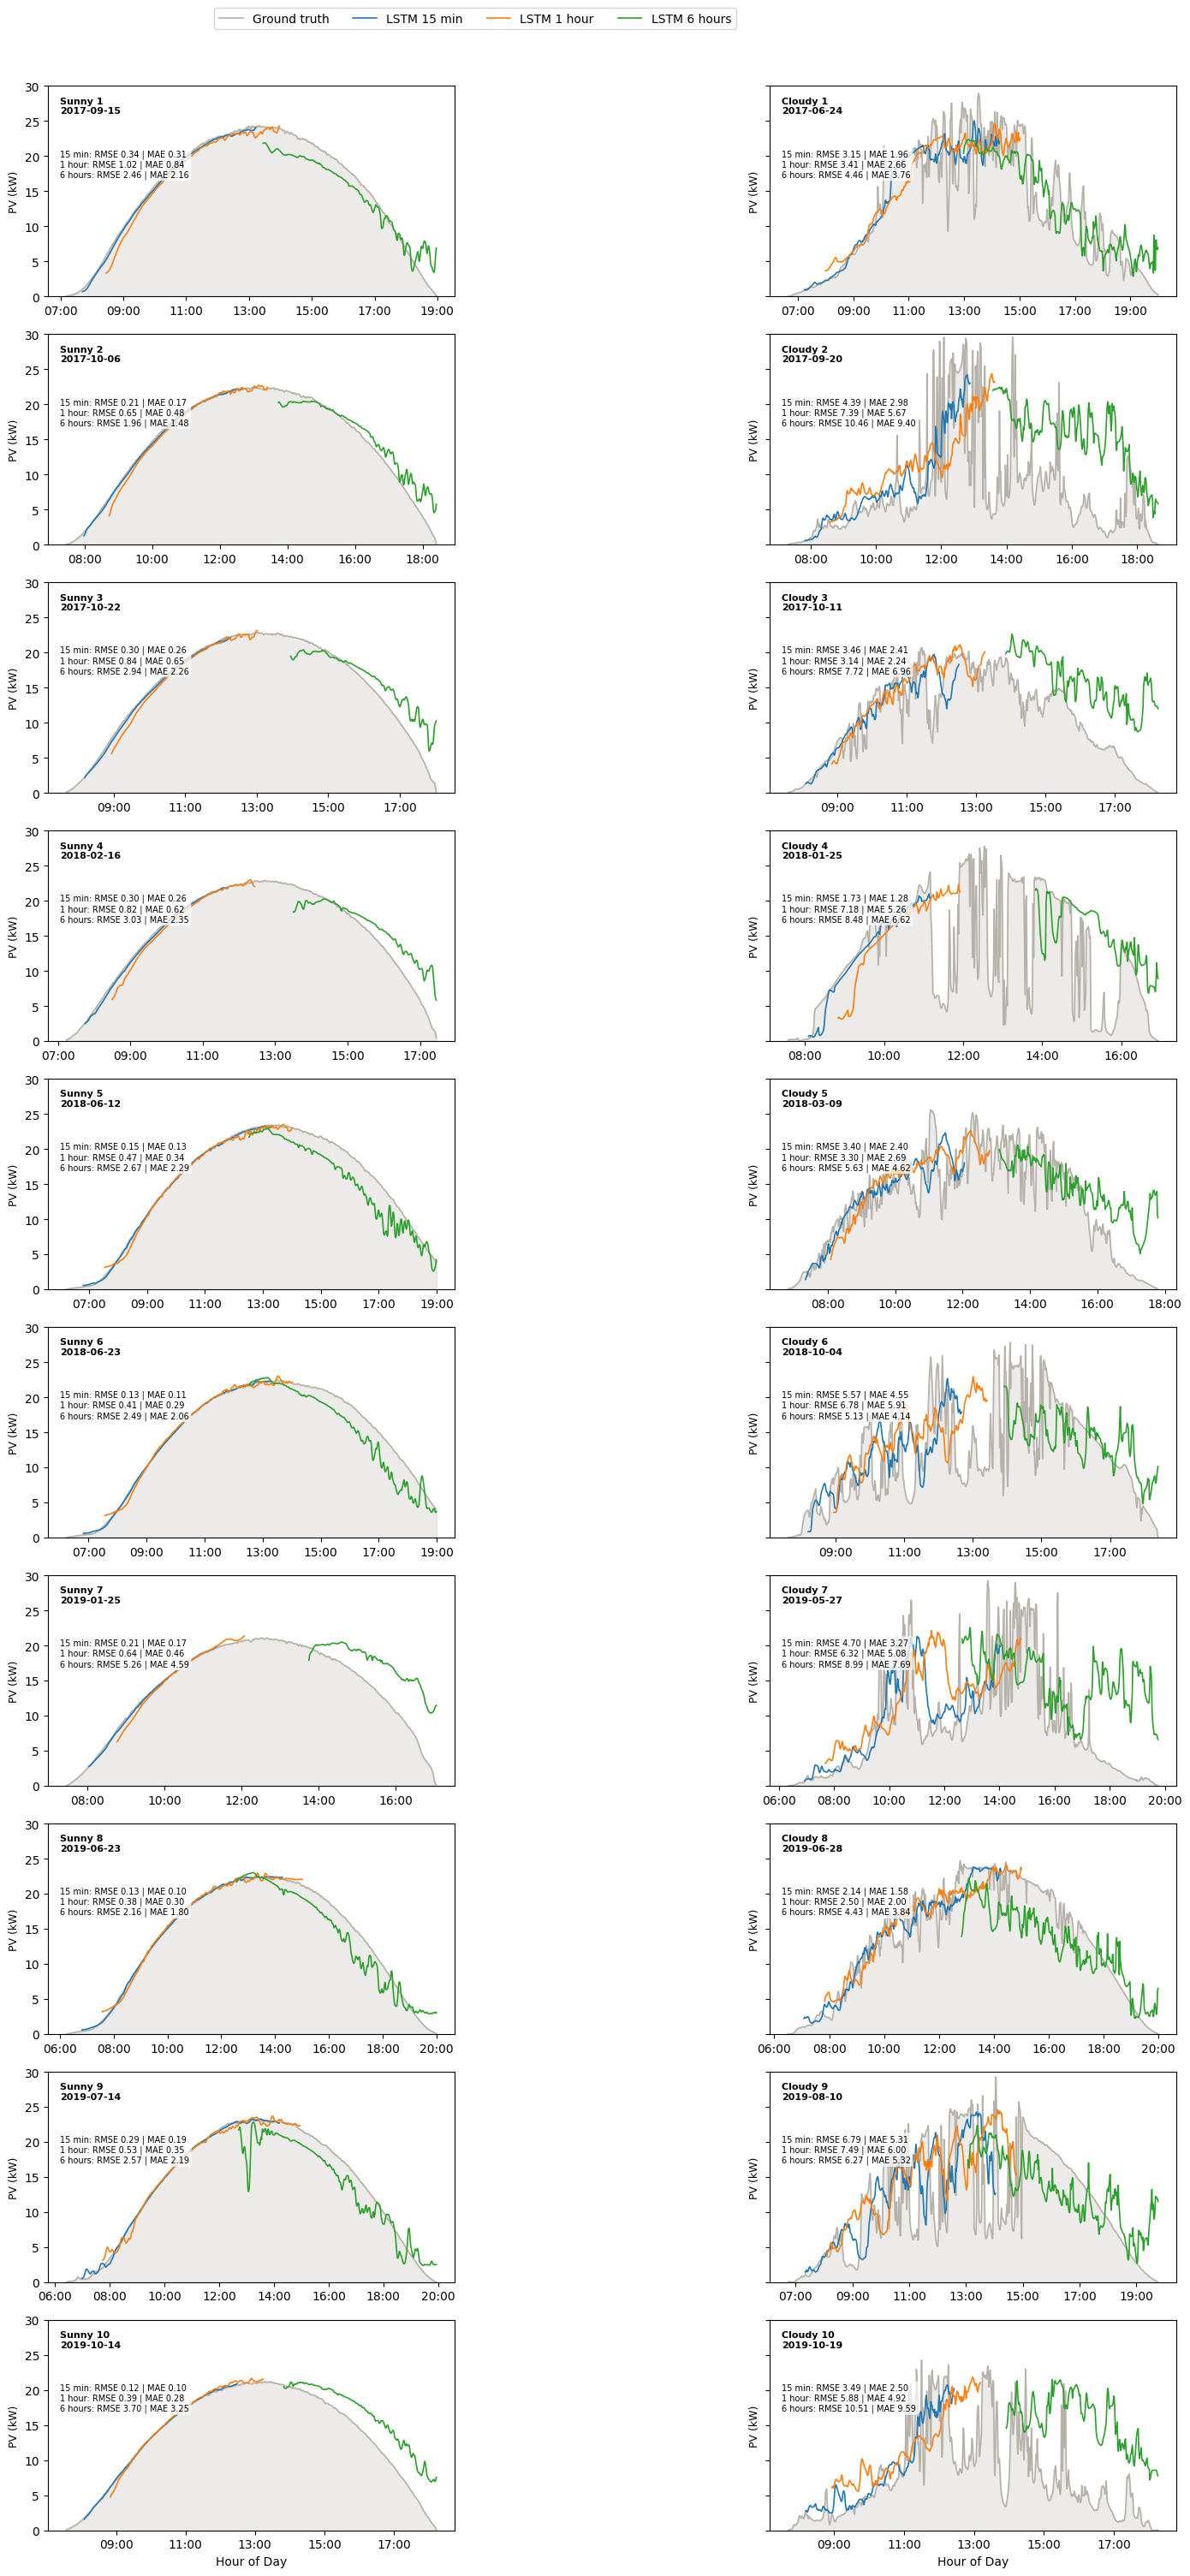

In [16]:
# Precompute full-day test dates to plot complete diurnal ground truth
dates_test_all = np.array(
    [
        (
            t.date()
            if isinstance(t, (datetime.datetime, datetime.date))
            else pd.to_datetime(t).date()
        )
        for t in times_test
    ]
)

# DAILY PROFILES EVALUATION: 10 SUNNY DAYS vs 10 CLOUDY DAYS
fig, axarr = plt.subplots(10, 2, sharex=False, sharey=True, figsize=(14, 30))

xfmt = mdates.DateFormatter("%H:%M")
fmt_date = datetime.date(2000, 1, 1)

COLOR_GT = "#B6B1A9"
HORIZON_COLORS = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
]  # Blue (15m), Orange (1h), Green (6h)


def plot_daily_forecast(ax, target_date, day_type_label, day_idx):
    date_mask = dates_test_seq == target_date
    if not np.any(date_mask):
        ax.text(0.5, 0.5, f"Date {target_date} not in test set", ha="center")
        return

    # Extract full-day ground truth from test_pv & times_test
    # (Fix: Avoid premature truncation caused by max_horizon=360 sequence construction)
    day_mask_full = dates_test_all == target_date
    if np.any(day_mask_full):
        times_day_full = times_test[day_mask_full]
        y_gt = test_pv[day_mask_full]
    else:
        times_day_full = (
            times_test_seq[date_mask, 0]
            if times_test_seq.ndim > 1
            else times_test_seq[date_mask]
        )
        y_gt = y_test[date_mask, 0] if y_test.ndim > 1 else y_test[date_mask]

    hours_xaxis_gt = [
        datetime.datetime.combine(
            fmt_date,
            (
                t.time()
                if isinstance(t, (datetime.datetime, datetime.time))
                else pd.to_datetime(t).time()
            ),
        )
        for t in times_day_full
    ]

    # Plot Full-Day Ground Truth
    ax.plot(
        hours_xaxis_gt,
        y_gt,
        color=COLOR_GT,
        linewidth=1.2,
        label="Ground truth" if (day_idx == 0 and day_type_label == "Sunny") else "",
    )
    ax.fill_between(hours_xaxis_gt, 0, y_gt, color=COLOR_GT, alpha=0.25)

    # Extract true values and predictions for this day
    y_true_day = y_test[date_mask]
    y_pred_day = ensemble_predictions[date_mask]

    # Plot Forecast for each horizon
    metric_text_lines = [f"{day_type_label} {day_idx + 1}\n{target_date}"]
    for k, (h_name, h_color) in enumerate(zip(HORIZON_NAMES, HORIZON_COLORS)):
        times_day_hk = (
            times_test_seq[date_mask, k]
            if times_test_seq.ndim > 1
            else times_test_seq[date_mask]
        )
        hours_xaxis_k = [
            datetime.datetime.combine(
                fmt_date,
                (
                    t.time()
                    if isinstance(t, (datetime.datetime, datetime.time))
                    else pd.to_datetime(t).time()
                ),
            )
            for t in times_day_hk
        ]

        y_pred_k = y_pred_day[:, k] if y_pred_day.ndim > 1 else y_pred_day
        y_true_k = y_true_day[:, k] if y_true_day.ndim > 1 else y_true_day

        d_rmse = np.sqrt(np.mean(np.square(y_true_k - y_pred_k)))
        d_mae = np.mean(np.abs(y_true_k - y_pred_k))

        ax.plot(
            hours_xaxis_k,
            y_pred_k,
            color=h_color,
            linewidth=1.2,
            label=(
                f"LSTM {h_name}" if (day_idx == 0 and day_type_label == "Sunny") else ""
            ),
        )
        metric_text_lines.append(f"{h_name}: RMSE {d_rmse:.2f} | MAE {d_mae:.2f}")

    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.xaxis.set_major_formatter(xfmt)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

    # Annotations
    ax.text(
        0.03,
        0.95,
        metric_text_lines[0],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
    )
    ax.text(
        0.03,
        0.70,
        "\n".join(metric_text_lines[1:]),
        transform=ax.transAxes,
        fontsize=7,
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="none"
        ),
    )


# Plot Sunny Days (Column 0)
for i, date in enumerate(sunny_dates_test):
    plot_daily_forecast(axarr[i, 0], date, "Sunny", i)

# Plot Cloudy Days (Column 1)
for i, date in enumerate(cloudy_dates_test):
    plot_daily_forecast(axarr[i, 1], date, "Cloudy", i)

axarr[0, 0].set_ylim(0, 30)
axarr[0, 0].legend(
    bbox_to_anchor=[1.05, 1.40], loc="upper center", ncol=4, frameon=True, fontsize=10
)

axarr[-1, 0].set_xlabel("Hour of Day", fontsize=10)
axarr[-1, 1].set_xlabel("Hour of Day", fontsize=10)

plt.tight_layout()
plt.show()